In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

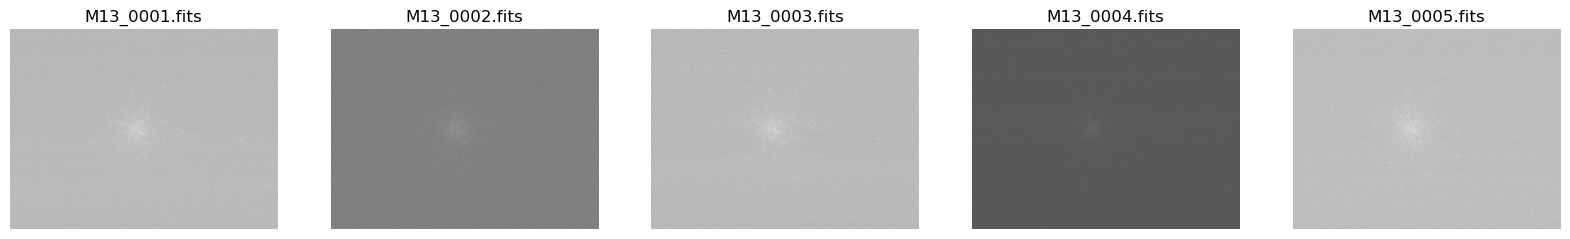

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
images = []
i = 1
while i < 6:
    with fits.open(f"M13_000{i}.fits") as hdul:
        header = hdul[0].header
        data = hdul[0].data
    images.append(data)
    ax = axes[i-1]
    ax.imshow(data, origin="lower", cmap="gray")
    ax.set_title(f"M13_000{i}.fits")
    ax.axis("off")
    i += 1
plt.show()

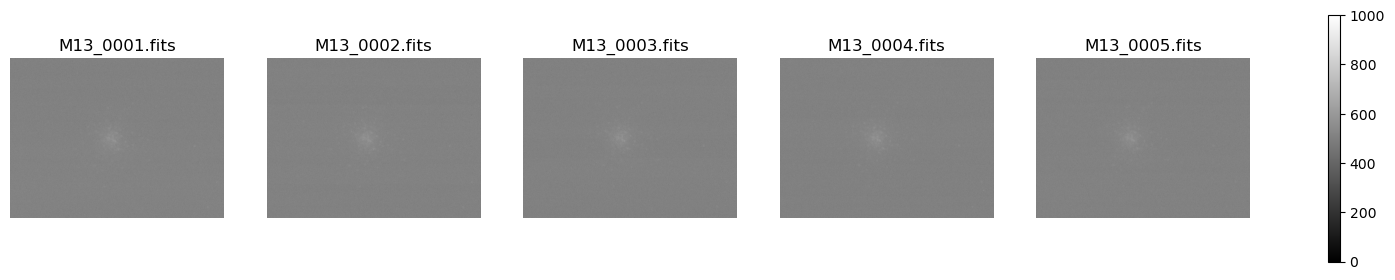

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (ax, data) in enumerate(zip(axes, images), start=1):
    im = ax.imshow(data, origin="lower", cmap="gray", vmin=0, vmax=1000)
    ax.set_title(f"M13_000{i}.fits")
    ax.axis("off")
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()

In [4]:
# 3.2) They all have a very similar color now

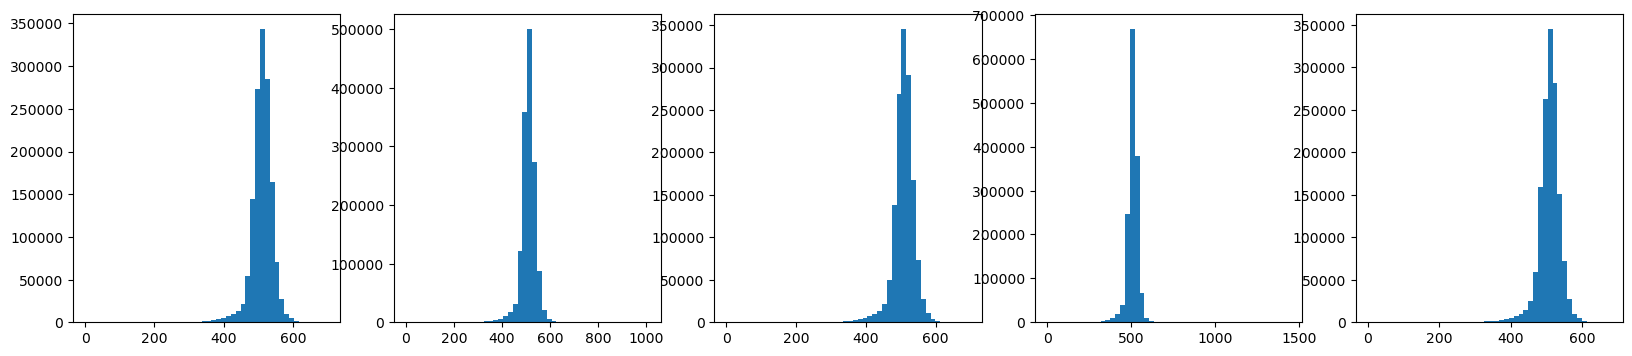

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, data, i in zip(axes, images, range(1, 6)):
    ax.hist(data.ravel(), bins=50)
plt.show()

In [6]:
# 3.3a) x-axis ranges betweewn 400 and 600, the y-xis ranges from 0 to 350000 for most but 700000 is the max
# 3.3b) The bin number is basically the amount of groups that we are using to group the x-data into
# 3.3c) the data seems to be most centered at 500
# 3.3d) The data is concentrated b/w 450 and 550

In [7]:
for data in images:
    mean_val = np.mean(data)
    median_val = np.median(data)
    print(mean_val)
    print(median_val)

510.4706668600796
512.0
509.7460150033157
511.0
508.0498729000884
510.0
507.90583554376656
509.0
508.7919920148099
510.0


In [8]:
# 3.3e) a little over 500 for each data set

In [30]:
stack = np.stack(images)
combined = np.median(stack, axis=0)
combined_median_value = np.median(combined)
print(combined_median_value)

510.0


In [31]:
# 3.4.1) The new median value is 510

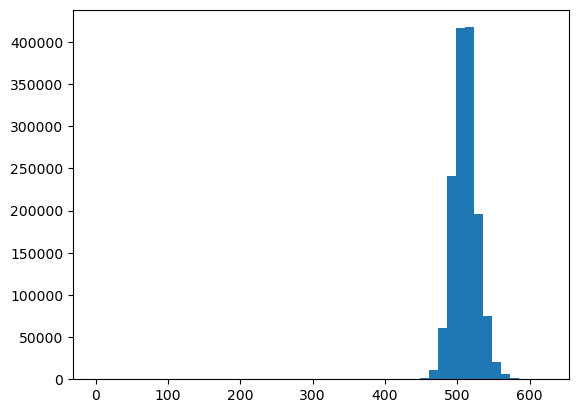

In [33]:
plt.hist(combined.ravel(), bins=50)
plt.show()

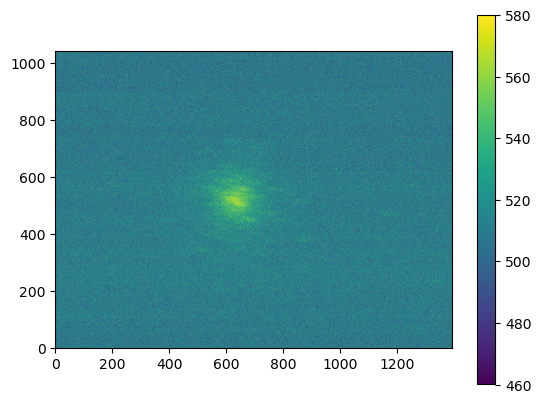

In [37]:
plt.imshow(combined, origin="lower", vmin=460, vmax=580)
plt.colorbar()
plt.show()

In [38]:
# 3.4.4) This image is much better than earlier versions

In [40]:
fits.writeto("combined.fits", combined, overwrite=True)